In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("bank.csv")
df.head(15)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


### Data Cleaning

In [3]:
# Check how many 'unknown' values exist in each column
for col in df.columns:
    count = df[df[col] == 'unknown'].shape[0]
    if count > 0:
        print(f"Column '{col}' has {count} unknown values")

Column 'job' has 70 unknown values
Column 'education' has 497 unknown values
Column 'contact' has 2346 unknown values
Column 'poutcome' has 8326 unknown values


In [4]:
# List of columns that typically have 'unknown'
cols_to_fix = ['job', 'education', 'contact', 'housing', 'loan']

for col in cols_to_fix:
    # Find the most common value (the mode)
    most_common = df[df[col] != 'unknown'][col].mode()[0]
    
    # Replace 'unknown' with that value
    df[col] = df[col].replace('unknown', most_common)

print("All 'unknown' values replaced with the most frequent value.")

All 'unknown' values replaced with the most frequent value.


In [5]:
# Fixing the pdays logic: Replace 999 with -1 to tell the model 'this is a new customer'
df['pdays'] = df['pdays'].replace(999, -1)
print("Fixed pdays logic.")

Fixed pdays logic.


In [6]:
# Count duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates removed.")

Duplicates found: 0
Duplicates removed.


### Scaling

In [7]:
x = df.drop("deposit", axis = 1)

In [8]:
y = df["deposit"]

In [9]:
# Lets seperate Numerical part from the Dataset
x_num = x.select_dtypes([int, float])
x_num

,age,balance,day,duration,campaign,pdays,previous
0,59,2343,5,1042,1,-1,0
1,56,45,5,1467,1,-1,0
2,41,1270,5,1389,1,-1,0
3,55,2476,5,579,1,-1,0
4,54,184,5,673,2,-1,0
...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0
11158,39,733,16,83,4,-1,0
11159,32,29,19,156,2,-1,0
11160,43,0,8,9,2,172,5


In [10]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
X_Scaled =ss.fit_transform(x_num)

In [11]:
X_Scaled 

array([[ 1.49150488,  0.25252514, -1.26574556, ..., -0.55416834,
        -0.48118405, -0.36325984],
       [ 1.23967567, -0.4599736 , -1.26574556, ..., -0.55416834,
        -0.48118405, -0.36325984],
       [-0.0194704 , -0.0801603 , -1.26574556, ..., -0.55416834,
        -0.48118405, -0.36325984],
       ...,
       [-0.77495804, -0.46493443,  0.39689074, ..., -0.18678537,
        -0.48118405, -0.36325984],
       [ 0.14841574, -0.47392593, -0.90946635, ..., -0.18678537,
         1.10957066,  1.81833188],
       [-0.6070719 , -0.47392593, -0.79070662, ..., -0.55416834,
        -0.48118405, -0.36325984]], shape=(11162, 7))

In [12]:
Scaled_Data = pd.DataFrame(X_Scaled,columns = x_num.columns)
Scaled_Data

,age,balance,day,duration,campaign,pdays,previous
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260
...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332


#### All the numerical columns have been Scaled

### Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
x_cat = x.select_dtypes(["object"])

In [15]:
x_cat

,job,marital,education,default,housing,loan,contact,month,poutcome
0,admin.,married,secondary,no,yes,no,cellular,may,unknown
1,admin.,married,secondary,no,no,no,cellular,may,unknown
2,technician,married,secondary,no,yes,no,cellular,may,unknown
3,services,married,secondary,no,yes,no,cellular,may,unknown
4,admin.,married,tertiary,no,no,no,cellular,may,unknown
...,...,...,...,...,...,...,...,...,...
11157,blue-collar,single,primary,no,yes,no,cellular,apr,unknown
11158,services,married,secondary,no,no,no,cellular,jun,unknown
11159,technician,single,secondary,no,no,no,cellular,aug,unknown
11160,technician,married,secondary,no,no,yes,cellular,may,failure


In [16]:
LE = LabelEncoder()
for i in x_cat:
    x_cat[i] = LE.fit_transform(x_cat[i])
x_cat

,job,marital,education,default,housing,loan,contact,month,poutcome
0,0,1,1,0,1,0,0,8,3
1,0,1,1,0,0,0,0,8,3
2,9,1,1,0,1,0,0,8,3
3,7,1,1,0,1,0,0,8,3
4,0,1,2,0,0,0,0,8,3
...,...,...,...,...,...,...,...,...,...
11157,1,2,0,0,1,0,0,0,3
11158,7,1,1,0,0,0,0,6,3
11159,9,2,1,0,0,0,0,1,3
11160,9,1,1,0,0,1,0,8,0


#### All the categorical columns are Encoded

In [17]:
# Concatenating the Numerical and categorical dataframees
x_final = pd.concat((Scaled_Data, x_cat), axis = 1) # Scaled_Data x_cat
x_final

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,0,1,1,0,1,0,0,8,3
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,0,1,1,0,0,0,0,8,3
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,9,1,1,0,1,0,0,8,3
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,7,1,1,0,1,0,0,8,3
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,0,1,2,0,0,0,0,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,1,2,0,0,1,0,0,0,3
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,7,1,1,0,0,0,0,6,3
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,9,2,1,0,0,0,0,1,3
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,9,1,1,0,0,1,0,8,0


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test  =  train_test_split(x_final,y,train_size = 0.8, random_state = 42)

In [19]:
print(f"Training set size: {x_train.shape[0]} rows")
print(f"Testing set size: {x_test.shape[0]} rows")

Training set size: 8929 rows
Testing set size: 2233 rows


In [20]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the model
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# 2. Train the model (this is where the 'learning' happens)
clf.fit(x_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [21]:
from sklearn.metrics import accuracy_score

# 1. Predictions on Training Data
train_predictions = clf.predict(x_train)
train_accuracy = accuracy_score(y_train, train_predictions)

# 2. Predictions on Testing Data
test_predictions = clf.predict(x_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 80.39%
Testing Accuracy: 78.19%


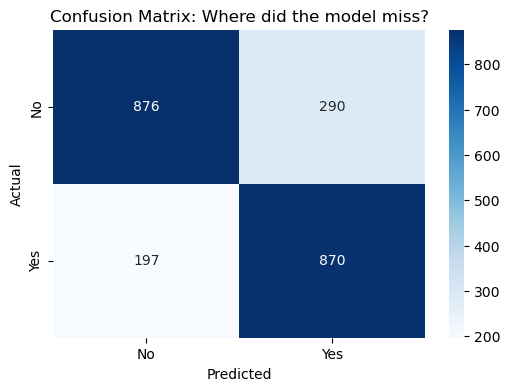

In [22]:
from sklearn.metrics import confusion_matrix
# Generate the matrix
cm = confusion_matrix(y_test, test_predictions)
# Visualize it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where did the model miss?')
plt.show()

#### Model is remarkably balanced. Usually, in bank datasets, the False Negative count is much higher because "Yes" events are rare. Having 870 True Positives suggests your preprocessing and decision tree depth are working very well.

##### True Negatives (Top-Left: 876): You correctly predicted 876 people would not subscribe.
##### True Positives (Bottom-Right: 870): You correctly identified 870 people who did subscribe. This is excellent!
##### False Positives (Top-Right: 290): These are "False Alarms." You predicted they would buy, but they didn't.
##### False Negatives (Bottom-Left: 197): These are "Missed Opportunities." You predicted they wouldn't buy, but they actually would have.

#### Balancing the above model 

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the model with 'balanced' weights. 
# This automatically handles the fact that there are fewer 'Yes' than 'No'.
clf = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=6,             # Slightly deeper for more detail
    min_samples_leaf=10,     # Prevents the model from being too sensitive to outliers
    class_weight='balanced', # CRITICAL: Gives more weight to 'Yes' subscribers
    random_state=42
)

# Train the model
clf.fit(x_train, y_train)

# Calculate Accuracy
train_acc = accuracy_score(y_train, clf.predict(x_train))
test_acc = accuracy_score(y_test, clf.predict(x_test))

print(f"Corrected Training Accuracy: {train_acc * 100:.2f}%")
print(f"Corrected Testing Accuracy: {test_acc * 100:.2f}%")

Corrected Training Accuracy: 80.73%
Corrected Testing Accuracy: 79.04%


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, clf.predict(x_test)))

              precision    recall  f1-score   support

          no       0.83      0.75      0.79      1166
         yes       0.75      0.84      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233

